<a href="https://colab.research.google.com/github/IsabelaBersan/tech-challenge-fase2/blob/main/notebooks/4_avaliacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 8. MODELO DE MACHINE LEARNING

### 8.1 KNN


### 8.1.1 Matriz de Confusão - 11 Variáveis

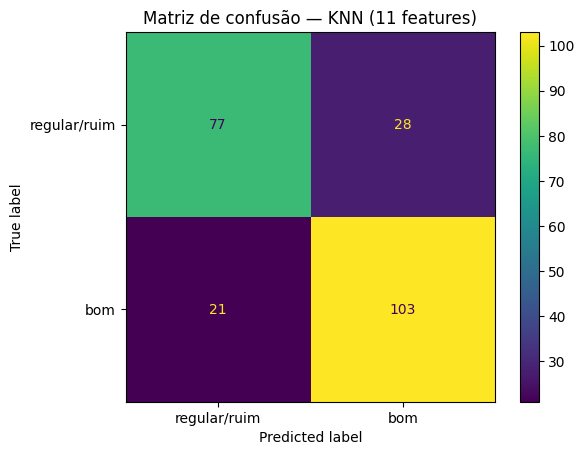

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
matriz_confusao = confusion_matrix(y_true=y_test,
                                   y_pred=y_pred,
                                   labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=['regular/ruim', 'bom'])
disp.plot(values_format='d')
plt.title('Matriz de confusão — KNN (11 features)')
plt.show()

### 8.1.2 Matriz de Confusão 4 váriavies mais correlacionadas

<Figure size 600x500 with 0 Axes>

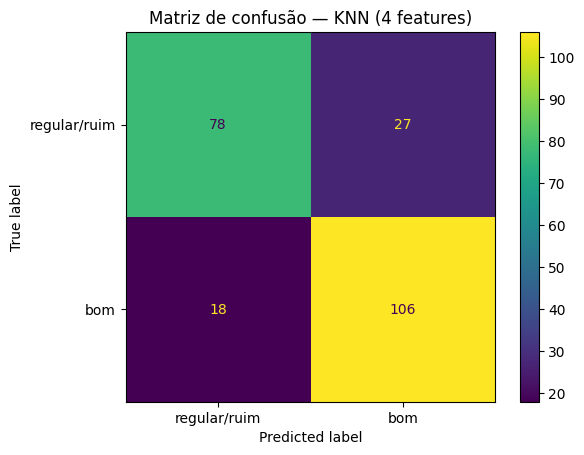

In [ ]:
matriz_confusao = confusion_matrix(y_true=y_test_corr,
                                   y_pred=y_pred_corr,
                                   labels=[0, 1])

figure = plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=['regular/ruim', 'bom'])
disp.plot(values_format='d')
plt.title('Matriz de confusão — KNN (4 features)')
plt.show()

### 8.1.7 Observações - KNN

**-- Accuracy**

O KNN foi testado com dois conjuntos de variáveis. Com as 11 variáveis físico-químicas, a acurácia foi de 78,6%; com as 4 de maior correlação, 80,3%. Ambos bem acima da baseline de 54,2%.

**-- Matriz de Confusão**
As matrizes de confusão mostram que o modelo erra mais ao aprovar do que ao reprovar: com 4 variáveis, foram 27 vinhos regulares classificados como bons contra 18 bons classificados como regulares. Ou seja, é mais permissivo que restritivo.

A diferença de 1,7 ponto entre os conjuntos equivale a 4 vinhos de 229 e não é significativa. A vantagem do conjunto reduzido é prática: mesmo desempenho medindo 4 variáveis em vez de 11.

Como limitação, o dataset mantém 125 linhas duplicadas (10,9%, seção 2.4), o que tende a tornar as métricas do KNN levemente otimistas.


### 8.2 SVM

### 8.2.3 Matriz de Confusão - 11 variáveis

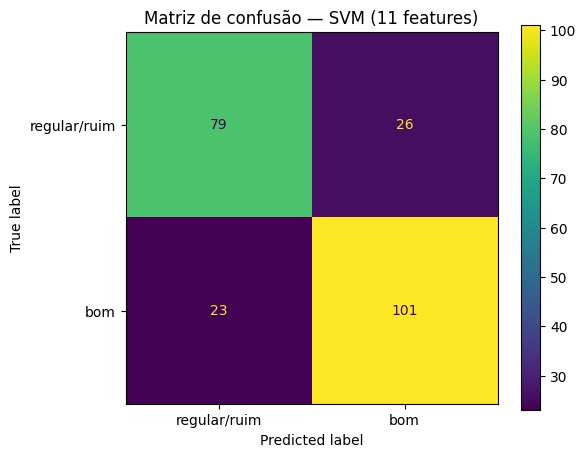

In [ ]:
matriz_confusao_svm = confusion_matrix(y_true=y_test,
                                       y_pred=y_pred_svm,
                                       labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_svm,
                              display_labels=['regular/ruim', 'bom'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(values_format='d', ax=ax)
ax.set_title('Matriz de confusão — SVM (11 features)')
plt.show()

### 8.2.5 Matriz de Confusão 4 variáveis mais correlacionadas

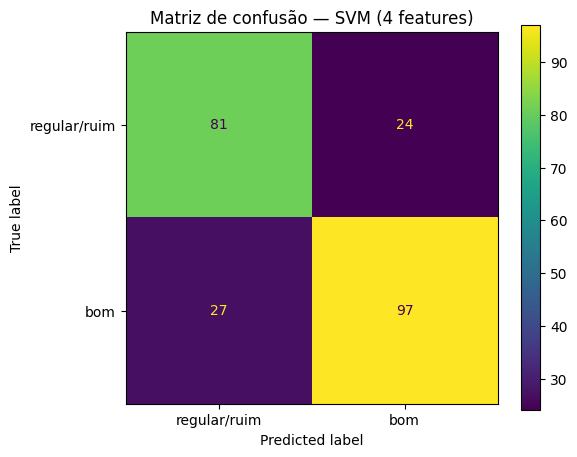

In [ ]:
matriz_confusao_svm = confusion_matrix(y_true=y_test_corr,
                                       y_pred=y_pred_svm_corr,
                                       labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_svm,
                              display_labels=['regular/ruim', 'bom'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(values_format='d', ax=ax)
ax.set_title('Matriz de confusão — SVM (4 features)')
plt.show()

o SVM de 4 features é o mais conservador de todos os modelos até agora — só 24 falsos positivos, o menor número. Ele acerta mais vinhos regulares (81) e menos vinhos bons (97). Enquanto o KNN tende a aprovar demais, esse tende a reprovar

### 8.2.7 Observações SVM

-- Accuracy

O SVM foi testado com os mesmos dois conjuntos. Com as 11 variáveis, a acurácia foi de 78,6%; com as 4 de maior correlação, 77,7%. Ambos bem acima da baseline de 54,2%.

As matrizes de confusão mostram o comportamento oposto ao do KNN: com 4 variáveis, foram 24 vinhos regulares classificados como bons contra 27 bons classificados como regulares. Ou seja, o modelo é mais restritivo que permissivo.

A diferença de 0,9 ponto entre os conjuntos equivale a 2 vinhos de 229 e não é significativa. Diferente do KNN, o SVM piora levemente ao reduzir para 4 variáveis, pois o kernel RBF já pondera as dimensões internamente.

-- Curva ROC

O AUC foi de 0,842 com 11 variáveis e 0,838 com 4. Ambos bem acima de 0,5, confirmando boa separação das classes.


Como o AUC e acurácia medem coisas diferentes, não devem ser comparadas entre si. Com 4 váriavies mais correlacionadas o modelo acaba performando pior.

## 9. Variáveis com influência na qualidade do vinho

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Accuracy: 0.4585
alcohol                 0.200165
sulphates               0.135361
total sulfur dioxide    0.104786
volatile acidity        0.098917
density                 0.080237
chlorides               0.072327
pH                      0.066914
fixed acidity           0.065777
citric acid             0.061212
free sulfur dioxide     0.060169
residual sugar          0.054135
dtype: float64


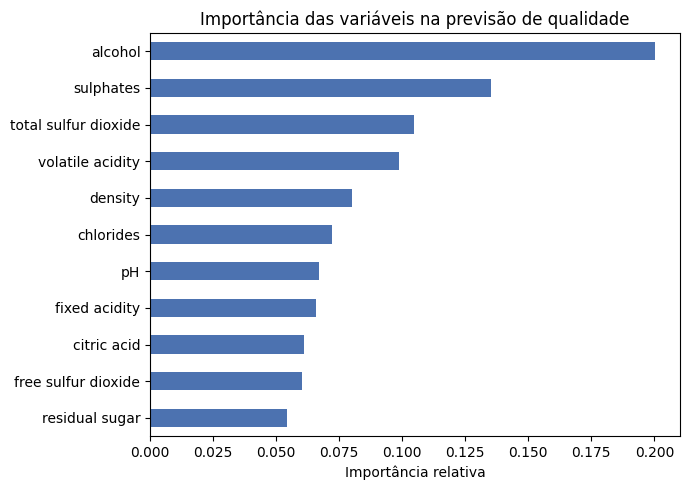

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(x_train_escalonado, y_train)
y_pred_rf = rf.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Etapa 6 — variáveis mais influentes
importancias = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print(importancias)

importancias.plot(kind='barh', figsize=(7,5), color='#4C72B0')
plt.title('Importância das variáveis na previsão de qualidade')
plt.xlabel('Importância relativa')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

O modelo Random Forest foi desenvolvido utilizando as 11 variáveis físico-químicas disponíveis na base, mantendo a representação completa das características do vinho. O gráfico de importância permite identificar quais variáveis apresentaram maior contribuição para as previsões do modelo.

Esse resultado complementa a matriz de correlação apresentada anteriormente, na qual álcool e acidez volátil apresentaram as maiores associações com a qualidade, seguidos por sulfatos e ácido cítrico. A comparação entre as duas análises permite verificar se as variáveis que apresentaram maior correlação com quality também possuem maior relevância para o modelo. Ressalta-se, porém, que a importância das variáveis indica contribuição preditiva, não relação de causalidade.

## 10. Implicações para o processo de produção

Os resultados podem apoiar o processo de produção ao indicar quais características físico-químicas estão mais relacionadas à classificação da qualidade. Variáveis como álcool, acidez volátil, sulfatos e ácido cítrico, que apresentaram maior associação com quality na matriz de correlação, também podem ser acompanhadas como indicadores de controle e monitoramento dos lotes.

Na prática, o modelo pode ser utilizado como uma ferramenta de apoio ao controle de qualidade, permitindo identificar previamente lotes com maior probabilidade de serem classificados como regulares ou bons e direcionar análises mais detalhadas quando necessário. Entretanto, os resultados não devem ser interpretados como relações de causa e efeito nem utilizados isoladamente para decisões de produção, sendo necessária a validação do modelo com dados reais e independentes do processo produtivo.